# Household invoice generator

Bills for the real metering points under `Input data/Poraba doma/`, in the
line-item layout of a Slovenian invoice — per month, per calendar year, or over
the whole export.

Everything goes through `import Pricing_Functions as pf`. The settlement is
`si_invoice.InvoiceBuilder`, the same driver the RL environment and the MILP
benchmark invoice through; this notebook only selects, displays and exports.

| Folder | Merilno mesto | Cenik | Tarifa |
|---|---|---|---|
| `Adamiceva` | 3-68420 | `ELEN_ZANESLJIVA` | 2T (VT/MT) |
| `Posavskega` | 3-83783 | `ELEN_ZANESLJIVA` | 2T (VT/MT) |
| `Koroska` | 3-83472 | `GENI_REDNI_1T` | 1T (ET) |

In [1]:
import sys
from dataclasses import replace
from pathlib import Path

import pandas as pd
from matplotlib import pyplot as plt

# `Pricing_Functions` at the repo root is a shim over "New pricing functions/",
# whose modules import each other by plain name (`from si_invoice import ...`).
# Reloading the shim alone re-executes the shim but leaves those siblings at
# whatever version the kernel first imported, so an edited si_invoice.py comes
# back as "cannot import name ... from si_invoice". Dropping the whole namespace
# forces one consistent reload of the set.
for _name in [n for n in sys.modules
              if n.startswith(("si_", "_household_")) or n == "Pricing_Functions"]:
    del sys.modules[_name]

import Pricing_Functions as pf

pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 200)

print("Configured:", pf.household_names())
if pf.unconfigured_folders():
    print("Profile folders without a price list:", pf.unconfigured_folders())

Configured: ['Adamiceva', 'Posavskega', 'Koroska']


In [2]:
### SETUP — everything this notebook does is decided here
HOUSEHOLD = "Posavskega"          # pf.household_names()
INVOICE_MODE = "monthly"          # "monthly" | "yearly" | "period"
INVOICE_YEAR, INVOICE_MONTH = 2026, 6

SCHEME = "si_dobava"              # "si_dobava" = grid supply only
                                  # "si_samooskrba" = PV self-supply; settles the
                                  # export's A- column, needs a PV price list
PAKET_ID = None                   # None keeps this household's catalogue cenik
EKO_RACUN = True                  # e-invoice discount on the supplier's monthly fee

# Connection from the soglasje (pf.PRIKLJUCNE_MOCI_KW); it sets the floor and the
# ceiling on the agreed power, and the administrative power when there is no
# history. None = soglasje unknown: no floor, no ceiling, so the agreed power
# follows the measured peaks and the monotonicity rule alone, which beats
# inventing a connection size and then billing the household against it. A
# contract year with neither a DSO figure nor peaks to read then has nothing to
# fall back on and raises, because there is no administrative power without a
# connection — pin that year in pf.RACUNI_MOCI instead.
VAROVALKA = "3x16"                # "3x16" | ... | None

# --- dogovorjena obračunska moč -------------------------------------------
# VIR_MOCI decides where the per-block kW vector comes from for every block not
# pinned below. Every mode falls back to the administrative power for this
# connection when its own source turns up empty.
#   "auto"            the export's "Dogovorjena moč" column, with the operator's
#                     rule filling the blocks that column omits
#   "dso"             that column alone
#   "operater"        the operator's rule alone, ignoring the column
#   "administrativna" the no-history figure for this connection
# The rule (uro.si): mean of the five highest 15-minute peaks per block over
# Oct(y-2)..Sep(y-1), blocks 1-4 only, rounded to 0.1 kW, floored at the
# connection's published minimum, then raised so no block sits below a lower one
# — which is what sets block 5. It reads only settled readings, and a window
# holding fewer than 12 months of them prints a warning: that figure is an
# estimate, not the operator's, and belongs pinned from the bill.
VIR_MOCI = "auto"                 # "auto" | "dso" | "operater" | "administrativna"

# Figures copied off the paper bill live on the household itself, in
# `pf.RACUNI_MOCI`, so the CLI and this notebook bill the same thing — they are a
# property of the metering point, not of one notebook. Posavskega's 2026 vector
# is pinned there because its export holds 1 of the 12 settled months the
# operator's rule needs. Set DOGOVORJENA_MOC here only to override that:
# {blok: kW} or {(leto, mesec): {blok: kW}}, billed VERBATIM — no floor, no
# ceiling, no monotonicity clipping — and applied PER BLOCK, so blocks you do not
# name keep their resolved figure (a summer bill's {2,3,4,5} still gets a block 1
# in winter). Use {} to drop the pin and bill VIR_MOCI's own figure instead.
DOGOVORJENA_MOC = None            # None -> whatever the catalogue carries

OBRACUNAJ_PRESEZNO_MOC = False    # exempt while the operator sets the power and
                                  # the household never changes it (Ur. l. RS 27/25)

# --- range and presentation ------------------------------------------------
MONTH_FROM, MONTH_TO = (2025, 1), None   # published SI tariffs start 2025-01
COMPLETE_MONTHS_ONLY = True       # a partial month still bills a full month of fixed charges
ROUND_LIKE_INVOICE = True         # whole kWh / 0.1 kW, amounts re-derived from them
VERIFY_BLOCKS = False             # cross-check every block against the DSO column
EXPORT_DIR = Path("Results/Invoices/Household").resolve()

catalogue = pf.get_household(HOUSEHOLD)
household = replace(
    catalogue,
    scheme=SCHEME,
    paket_id=PAKET_ID or catalogue.paket_id,
    eko_racun=EKO_RACUN,
    varovalka=VAROVALKA,
    prikljucna_moc_kw=None,       # re-derived from VAROVALKA
    vir_moci=VIR_MOCI,
    dogovorjena_moc=catalogue.dogovorjena_moc
                    if DOGOVORJENA_MOC is None else DOGOVORJENA_MOC,
    obracunaj_presezno_moc=OBRACUNAJ_PRESEZNO_MOC,
)
print(f"{household.name} | {household.paket_id} | {household.scheme} | "
      f"{pf.opis_prikljucka(household)} | "
      f"{INVOICE_MODE} {INVOICE_MONTH:02d}/{INVOICE_YEAR}")

Posavskega | ELEN_ZANESLJIVA | si_dobava | 3x16 / 11 kW | monthly 06/2026


In [3]:
### Price every interval, close every month
result = pf.invoice_household(
    household,
    month_from=MONTH_FROM,
    month_to=MONTH_TO,
    complete_months_only=COMPLETE_MONTHS_ONLY,
    round_like_invoice=ROUND_LIKE_INVOICE,
    check_blocks=VERIFY_BLOCKS,
)
print(f"\nInvoiced: {[f'{m:02d}/{y}' for y, m in result.months]}")


Posavskega  (Elektro energija – Zanesljiva oskrba (redni cenik), si_dobava, 3x16 / 11 kW)
  profile       35616 intervals, 2025-07-26 00:00 .. 2026-07-31 23:45, 6416.1 kWh in
  note          0.013 kWh of A- readings (0.0002% of intake) ignored as meter noise
  skipped       07/2025: 576 of 2976 intervals
  agreed power  2025: {1: 3.5, 2: 5.0, 3: 5.0, 4: 5.0, 5: 5.0}  [dso]
  agreed power  2026: {1: 2.8, 2: 4.0, 3: 4.3, 4: 4.3, 5: 4.3}  [operater, 1/12 months in the reference window]
  warning       2026: the operator's rule needs a full reference year of settled readings; this window holds 1/12 month(s) — pin dogovorjena_moc from the bill instead
  agreed power  blocks [2, 3, 4, 5] pinned in 7/12 invoiced month(s); other blocks resolved as above


  note          08/2025: rounded block quantities sum to +1 kWh against the stated intake
  note          10/2025: rounded block quantities sum to -1 kWh against the stated intake
  note          02/2026: rounded block quantities sum to -1 kWh against the stated intake
  note          06/2026: rounded block quantities sum to +1 kWh against the stated intake
  note          07/2026: rounded block quantities sum to +1 kWh against the stated intake

Invoiced: ['08/2025', '09/2025', '10/2025', '11/2025', '12/2025', '01/2026', '02/2026', '03/2026', '04/2026', '05/2026', '06/2026', '07/2026']


In [4]:
### The agreed billing power each month was settled on
# What is actually billed, pins included — check it against the "Dogovorjena moč"
# block on the paper invoice. Blocks 1 and 5 are seasonal (1 = Nov-Feb,
# 5 = Mar-Oct) and are only billed in months they occur in, but every month
# carries a figure for all five.
agreed = pd.DataFrame(
    {f"{m:02d}/{y}": result.schedule[(y, m)] for y, m in result.months}
).sort_index()
agreed.index.name = "blok"
display(agreed)

# The rule on its own, ignoring RACUNI_DOGOVORJENA_MOC: `izracunano` is what the
# five-highest-peaks rule reconstructs, `poroca_operater` what the export's own
# column states, `ujemanje` whether they agree. Read `mesecev_v_oknu` first — the
# rule needs a full 12 months of settled readings in Oct(y-2)..Sep(y-1), and
# settled readings only start on 1. 10. 2024. Adamiceva has them and reproduces
# the operator exactly; Posavskega's window holds 1 month, so its `izracunano` is
# an estimate rather than a failed reproduction, which is why its 2026 figure is
# pinned off the bill instead.
pf.validate_agreed_power(HOUSEHOLD, household)

,08/2025,09/2025,10/2025,11/2025,12/2025,01/2026,02/2026,03/2026,04/2026,05/2026,06/2026,07/2026
blok,,,,,,,,,,,,
1,3.5,3.5,3.5,3.5,3.5,2.8,2.8,2.8,2.8,2.8,2.8,2.8
2,5.0,5.0,5.0,5.0,5.0,3.8,3.8,3.8,3.8,3.8,3.8,3.8
3,5.0,5.0,5.0,5.0,5.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0
4,5.0,5.0,5.0,5.0,5.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0
5,5.0,5.0,5.0,5.0,5.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0


,leto,mesecev_v_oknu,izracunano,poroca_operater,ujemanje
0,2025,0,None,"{2: 5.0, 3: 5.0, 4: 5.0, 5: 5.0}",None
1,2026,1,"{1: 2.8, 2: 4.0, 3: 4.3, 4: 4.3, 5: 4.3}",None,None


In [5]:
### Month-by-month overview
composition = result.composition()
composition

,leto,mesec,Energija,Omrežnina,Prispevki in trošarina,Poslovanje,DDV,Za plačilo,Prevzeto [kWh],Povprečna cena [EUR/kWh]
obdobje,,,,,,,,,,
08/2025,2025,8,49.73,13.52,4.97,1.18,15.27,84.66,442.0,0.1915
09/2025,2025,9,61.36,15.22,5.20,1.18,18.25,101.20,536.0,0.1888
10/2025,2025,10,73.69,17.34,5.48,1.18,21.49,119.18,652.0,0.1828
11/2025,2025,11,82.14,25.11,3.17,1.18,24.55,136.15,736.0,0.1850
12/2025,2025,12,94.54,27.02,3.40,1.18,27.75,153.90,832.0,0.1850
01/2026,2026,1,81.26,22.53,2.87,1.18,23.73,131.57,726.0,0.1812
02/2026,2026,2,56.19,18.25,2.31,1.18,17.15,95.08,498.0,0.1909
03/2026,2026,3,57.19,14.45,4.19,1.18,16.94,93.94,504.0,0.1864
04/2026,2026,4,49.81,13.30,4.03,1.18,15.03,83.35,440.0,0.1894


#### The selected invoice

`INVOICE_MODE` picks which one renders. `kategorija` stays as the index so the
section a line belongs to is visible; `opozorilo` rows are the accumulator
flagging an assumption it had to make.

In [6]:
if INVOICE_MODE == "monthly":
    selected_rows = result.month(INVOICE_YEAR, INVOICE_MONTH)
    selected_label = f"{INVOICE_MONTH:02d}/{INVOICE_YEAR}"
elif INVOICE_MODE == "yearly":
    selected_rows = result.year(INVOICE_YEAR)
    selected_label = str(INVOICE_YEAR)
elif INVOICE_MODE == "period":
    selected_rows = result.period()
    selected_label = "celotno obdobje"
else:
    raise ValueError(f"INVOICE_MODE must be monthly/yearly/period, got {INVOICE_MODE!r}")

if not selected_rows:
    raise ValueError(f"Nothing invoiced for {selected_label}. Available: "
                     f"{[f'{m:02d}/{y}' for y, m in result.months]}")

print(f"{household.name} | {result.paket_ime}")
print(f"{selected_label}: ZA PLAČILO {pf.invoice_total(selected_rows):.2f} EUR")
pf.invoice_frame(selected_rows)

Posavskega | Elektro energija – Zanesljiva oskrba (redni cenik)
06/2026: ZA PLAČILO 71.83 EUR


,Postavka,Količina,EM,Cena [EUR/EM],Znesek [EUR]
kategorija,,,,,
naslov,Elektro energija – Zanesljiva oskrba (redni ce...,NaN,NaN,NaN,NaN
energija,Električna energija MT,184.0,kWh,0.10290,18.93360
energija,Električna energija VT,183.0,kWh,0.12490,22.85670
skupaj,Skupaj električna energija,NaN,NaN,NaN,41.79030
omreznina,Dogovorjena moč za časovni blok 2,3.8,kW,1.09230,4.15074
omreznina,Dogovorjena moč za časovni blok 3,4.0,kW,0.28902,1.15608
omreznina,Dogovorjena moč za časovni blok 4,4.0,kW,0.02436,0.09744
omreznina,Dogovorjena moč za časovni blok 5,4.0,kW,0.00245,0.00980
omreznina,Prevzeta EE za časovni blok 2,113.0,kWh,0.01998,2.25774


In [7]:
### The other views
# Amounts sum exactly across months; unit prices are re-derived as a blended
# znesek/kolicina, because the network block rates are seasonal.
display(pd.DataFrame(
    [{"obdobje": f"{m:02d}/{y}", "za_placilo_eur": round(pf.invoice_total(rows), 2)}
     for (y, m), rows in sorted(result.by_month.items())]
).set_index("obdobje").T)

period_rows = result.period()
for label, rows in ([(str(y), result.year(y)) for y in result.years]
                    + [("celotno obdobje", period_rows)]):
    print(f"\n=== {label} -> {pf.invoice_total(rows):.2f} EUR ===")
    display(pf.invoice_frame(rows, drop_warnings=True))

obdobje,08/2025,09/2025,10/2025,11/2025,12/2025,01/2026,02/2026,03/2026,04/2026,05/2026,06/2026,07/2026
za_placilo_eur,84.66,101.2,119.18,136.15,153.9,131.57,95.08,93.94,83.35,80.41,71.83,54.5



=== 2025 -> 595.10 EUR ===


,Postavka,Količina,EM,Cena [EUR/EM],Znesek [EUR]
kategorija,,,,,
naslov,Elektro energija – Zanesljiva oskrba (redni ce...,NaN,NaN,NaN,NaN
energija,Električna energija MT,1726.0,kWh,0.102900,177.60540
energija,Električna energija VT,1472.0,kWh,0.124900,183.85280
skupaj,Skupaj električna energija,NaN,NaN,NaN,361.45820
omreznina,Dogovorjena moč za časovni blok 2,25.0,kW,0.912240,22.80600
omreznina,Dogovorjena moč za časovni blok 3,25.0,kW,0.162970,4.07425
omreznina,Dogovorjena moč za časovni blok 4,25.0,kW,0.004070,0.10175
omreznina,Dogovorjena moč za časovni blok 5,15.0,kW,0.000000,0.00000
omreznina,Prevzeta EE za časovni blok 2,1001.0,kWh,0.018330,18.34833



=== 2026 -> 610.68 EUR ===


,Postavka,Količina,EM,Cena [EUR/EM],Znesek [EUR]
kategorija,,,,,
naslov,Elektro energija – Zanesljiva oskrba (redni ce...,NaN,NaN,NaN,NaN
energija,Električna energija MT,1734.0,kWh,0.102900,178.42860
energija,Električna energija VT,1484.0,kWh,0.124900,185.35160
skupaj,Skupaj električna energija,NaN,NaN,NaN,363.78020
omreznina,Dogovorjena moč za časovni blok 1,5.6,kW,1.711261,9.58306
omreznina,Dogovorjena moč za časovni blok 2,26.6,kW,1.040854,27.68672
omreznina,Dogovorjena moč za časovni blok 3,28.0,kW,0.253006,7.08416
omreznina,Dogovorjena moč za časovni blok 4,28.0,kW,0.018563,0.51976
omreznina,Prevzeta EE za časovni blok 1,343.0,kWh,0.019980,6.85314



=== celotno obdobje -> 1205.78 EUR ===


,Postavka,Količina,EM,Cena [EUR/EM],Znesek [EUR]
kategorija,,,,,
naslov,Elektro energija – Zanesljiva oskrba (redni ce...,NaN,NaN,NaN,NaN
energija,Električna energija MT,3460.0,kWh,0.102900,356.03400
energija,Električna energija VT,2956.0,kWh,0.124900,369.20440
skupaj,Skupaj električna energija,NaN,NaN,NaN,725.23840
omreznina,Dogovorjena moč za časovni blok 2,51.6,kW,0.978541,50.49272
omreznina,Dogovorjena moč za časovni blok 3,53.0,kW,0.210536,11.15841
omreznina,Dogovorjena moč za časovni blok 4,53.0,kW,0.011727,0.62151
omreznina,Dogovorjena moč za časovni blok 5,35.0,kW,0.001400,0.04900
omreznina,Prevzeta EE za časovni blok 2,2050.0,kWh,0.018817,38.57475


#### Charts

What the bill is made of, and what it works out to per kWh, on a shared month
axis. Colors are the project's validated categorical order (slots 1–5), used in
stacking order so only adjacent pairs have to separate.

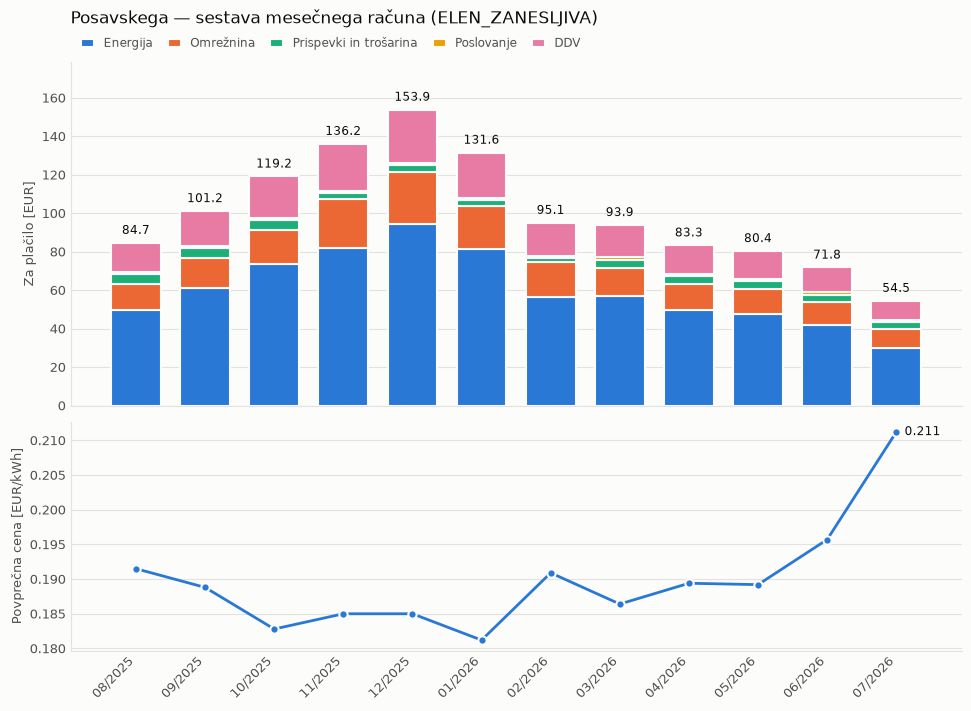

In [8]:
SURFACE, INK, INK_MUTED, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e3e2dd"
PART_COLORS = {
    "Energija": "#2a78d6",
    "Omrežnina": "#eb6834",
    "Prispevki in trošarina": "#1baf7a",
    "Poslovanje": "#eda100",
    "DDV": "#e87ba4",
}


def style_axes(ax):
    ax.set_facecolor(SURFACE)
    ax.grid(axis="y", color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(GRID)
    ax.tick_params(colors=INK_MUTED, labelsize=9, length=0)
    return ax


labels = list(composition.index)
x = range(len(labels))
fig, (ax_bill, ax_price) = plt.subplots(
    2, 1, figsize=(max(7, 0.55 * len(labels) + 3), 7),
    sharex=True, height_ratios=[3, 2], constrained_layout=True,
)
fig.patch.set_facecolor(SURFACE)

bottom = [0.0] * len(labels)
for part, color in PART_COLORS.items():
    values = composition[part].tolist()
    # A surface-colored edge is the 2px gap between stacked segments.
    ax_bill.bar(x, values, bottom=bottom, color=color, label=part,
                edgecolor=SURFACE, linewidth=1.5, width=0.72)
    bottom = [b + v for b, v in zip(bottom, values)]

# One direct label per bar -- the total -- rather than a number on every segment.
for xi, total in zip(x, composition["Za plačilo"]):
    ax_bill.text(xi, total + max(bottom) * 0.02, f"{total:,.1f}", ha="center",
                 va="bottom", fontsize=8.5, color=INK)

style_axes(ax_bill)
ax_bill.set_ylabel("Za plačilo [EUR]", color=INK_MUTED, fontsize=9.5)
ax_bill.set_title(f"{household.name} — sestava mesečnega računa ({household.paket_id})",
                  color=INK, fontsize=12, loc="left", pad=28)
ax_bill.legend(loc="lower left", bbox_to_anchor=(0, 1.005), ncol=5, frameon=False,
               fontsize=8.5, labelcolor=INK_MUTED, handlelength=1.1, columnspacing=1.3)
ax_bill.set_ylim(0, max(bottom) * 1.16)

prices = composition["Povprečna cena [EUR/kWh]"].tolist()
ax_price.plot(x, prices, color=PART_COLORS["Energija"], linewidth=2,
              marker="o", markersize=6, markeredgecolor=SURFACE, markeredgewidth=1.5)
ax_price.annotate(f"{prices[-1]:.3f}", (len(labels) - 1, prices[-1]),
                  textcoords="offset points", xytext=(6, 0), va="center",
                  fontsize=8.5, color=INK)
style_axes(ax_price)
ax_price.set_ylabel("Povprečna cena [EUR/kWh]", color=INK_MUTED, fontsize=9.5)
ax_price.set_xticks(list(x))
ax_price.set_xticklabels(labels, rotation=45, ha="right")
ax_price.margins(x=0.04)
plt.show()

In [9]:
### Export to Results/Invoices/Household
label = f"{household.name}_{household.paket_id}"
for name, rows in ([("monthly", result.rows), ("period", period_rows)]
                   + [(f"{y}_yearly", result.year(y)) for y in result.years]):
    pf.write_rows_csv(rows, EXPORT_DIR / f"{label}_{name}.csv")
composition.to_csv(EXPORT_DIR / f"{label}_composition.csv")
result.summary_frame().to_csv(EXPORT_DIR / f"{label}_summary.csv", index=False)

print("\n".join(str(p) for p in sorted(EXPORT_DIR.glob(f"{label}_*.csv"))))

C:\Users\HP\Documents\JupyterNotebook\Energy_Community\Results\Invoices\Household\Posavskega_ELEN_ZANESLJIVA_2025_yearly.csv
C:\Users\HP\Documents\JupyterNotebook\Energy_Community\Results\Invoices\Household\Posavskega_ELEN_ZANESLJIVA_2026_yearly.csv
C:\Users\HP\Documents\JupyterNotebook\Energy_Community\Results\Invoices\Household\Posavskega_ELEN_ZANESLJIVA_composition.csv
C:\Users\HP\Documents\JupyterNotebook\Energy_Community\Results\Invoices\Household\Posavskega_ELEN_ZANESLJIVA_monthly.csv
C:\Users\HP\Documents\JupyterNotebook\Energy_Community\Results\Invoices\Household\Posavskega_ELEN_ZANESLJIVA_period.csv
C:\Users\HP\Documents\JupyterNotebook\Energy_Community\Results\Invoices\Household\Posavskega_ELEN_ZANESLJIVA_summary.csv


#### What these numbers assume

- **Agreed power.** `pf.RACUNI_MOCI` pins a household's figure straight off its
  paper bill, on the `Household` in the catalogue, so this notebook and the
  `si_poraba_doma` CLI bill the same thing — the figure belongs to the metering
  point, not to one notebook. A pin is per block and billed verbatim — no floor,
  no ceiling, no monotonicity clipping; a non-monotone result is reported, not
  reshaped — and is keyed by `(leto, mesec)` so it cannot leak into a contract
  year it was not read off. `DOGOVORJENA_MOC` in SETUP overrides it for one run.
  Everything unpinned comes from `VIR_MOCI`, whose source is printed per year.
  The operator's rule reproduces Adamiceva's 2026 figure exactly
  (`{1: 2.8, 2: 3.5, 3: 3.5, 4: 3.5, 5: 3.5}` from raw peaks of
  2.797 / 3.473 / 2.968 / 2.590 kW), block 1 landing on the 2026 minimum for a
  3 × 16 A connection — that export covers 2023-08 onward, so its reference
  window is complete. Posavskega's is not: the export starts 26. 7. 2025 and
  07–08/2025 are marked `Obračunski podatek = Ne`, leaving **1 of 12 settled
  months** in 10/2024–09/2025. The rule then reads a single September and returns
  4.0 / 4.3 / 4.3 against the bill's 3.8 / 4.0 / 4.0, so 2026 is pinned.
  Widening the window is not the fix — over all 10 months present the blok 2
  figure rises to 5.7 kW, because Posavskega's autumn 2025 peaks (5.08 / 5.11 /
  5.38 kW in Oct–Dec) are far above the period the operator actually read. It
  would also break Adamiceva's exact match, moving its block 1 to 2.9 kW.
- **The connection may be unknown.** `VAROVALKA = None` (with no
  `prikljucna_moc_kw`) drops both the floor and the ceiling, so the agreed power
  follows the measured peaks and the monotonicity rule alone. That is the right
  model for an export with no soglasje, but it is not a better default for one
  that has it: without the floor a block with no peaks in the reference window
  resolves to 0 kW — a warning says which — and Adamiceva's exact match depends
  on the 2.8 kW floor. A year with neither a DSO figure nor peaks then raises,
  because there is no administrative power without a connection.
- **`ROUND_LIKE_INVOICE` changes the totals, not just the display.** The
  *quantity* is rounded (whole kWh, 0.1 kW) and the amount is that rounded
  quantity times the unrounded unit price; levies and excise reuse the intake the
  energy lines already state. It runs per month, because a year is the sum of
  twelve rounded invoices.
  Checked line by line against the real Posavskega 06/2026 bill: every line
  matches to the cent except one. The bill charges 19 kWh in block 5 where the
  export holds 20.280. The DSO's own `Blok` column agrees with ours on all 2 880
  intervals of that month, and the reason is visible in the `note` row — rounded
  independently the four blocks sum to 368 kWh while VT + MT rounds to 367, so
  the operator absorbed the odd kWh in block 5, the cheapest at
  0.01299 EUR/kWh. We report that gap instead of silently reallocating it, which
  leaves the bill at 58.87591 EUR against the paper 58.86292 EUR — a 0.01299 EUR
  difference on one line, nothing else.
- **Excess-power charge is off** — a household whose agreed power the operator
  sets and which never changes it is permanently exempt (Ur. l. RS 27/25).
  Posavskega peaks at 6.76 kW against agreed figures of 2.8–5.0 kW, so turning it
  on is not a small difference.
- **Only 2025-01-01 … 2026-12-31 have published tariffs.** The 2023/2024
  `Adamiceva` exports still price, but fall back to the 2026 regime.
  `ELEN_ZANESLJIVA` is valid from 2025-03-01, so 01–02/2025 extrapolate it
  backwards — that is the `opozorilo` row on those bills.
- A non-standard connection (not in `pf.PRIKLJUCNE_MOCI_KW`) is set with
  `prikljucna_moc_kw=` and `faze=` on the `Household` instead of `VAROVALKA`.